# Purpose: A2 motor neuron spike rate vs. probe position during movement bouts

For each A2-tagged cell in the Figure 4 sinq, build a Gaussian-smoothed firing-rate trace (σ = 25 ms, full kernel ≈ 100 ms), detect movement bouts on the camera-rate probe trace, and plot spike rate vs. probe position frame-by-frame. MOVE samples are the focus; REST and DRIFT are kept for comparison.

# Setup

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mapd
from mapd import Sinq
from mapd import bout_analysis as ba
from mapd.bout_analysis import SIGMA_S, RATE_WINDOWS_S, collect_cell_records

from figure7_analysis import (
    tag_suffix,
    plot_rate_vs_position,
    plot_cell_ccf,
    plot_cell_ccf_by_strength,
    plot_cell_ccf_by_sign,
    plot_velocity_histograms,
    print_bouts_per_bin,
    run_cell_quartile_analysis,
    run_cell_stim_analysis,
    # --- gathering (expensive) and analysis (cheap) are now separate ---
    build_cell_records,      # restore table -> padded per-frame records
    run_cell_rest_analysis,  # kernels + cue + premove + demo trials
    run_cell_window_analysis,  # the window sweep, optional
    run_cell_rest_window_analysis,  # legacy one-call = build + windows + Vm figs
    find_demo_trials,
    measure_blank_window,
    plot_rest_windows_scatter,
    plot_rest_window_summary,
    plot_rate_by_trial,
    plot_spike_sta,
    plot_vm_vs_rate,
    plot_vm_drift,
    plot_vm_vs_position_rest,
    pooled_spread_table,
    plot_rate_vs_vm_trial, plot_rate_vs_position_kernels, plot_bout_rate_spread, plot_cue_response,
    plot_bout_signal_correlation, plot_trial_vm_overlay,
    plot_trial_records,
    plot_drate_vs_dvm_trial,
    plot_bout_coupling_across_cells,
    plot_ccf_by_condition,
    plot_event_latency
)

%matplotlib widget
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load dataset 4 sinq, filter to A2-tagged cells

In [19]:
sinq = Sinq(sinqname='dataset_4_mns')
a2_ids = list(sinq.df.index[sinq.has_tag('A2')])
print(f'{len(a2_ids)} A2 cells:')
for i in a2_ids:
    print(' ', i)

# # 6 A2 cells:
#   210602_F1_C1
#   210604_F1_C1
#   210903_F3_C1
#   210908_F3_C1
#   210915_F1_C1
#   240430_F1_C1

Found data directory: D:\Data
6 A2 cells:
  210602_F1_C1
  210604_F1_C1
  210903_F3_C1
  210908_F3_C1
  210915_F1_C1
  240430_F1_C1


## Per-trial helper: rate + state vector at frame times

Rate is computed on the trial's camera-frame time base (`trial.time[trial.downsample_probe]`) so each frame contributes one `(position, rate, state)` sample to the scatter.

## Bouts by initiation position and initial speed

Each movement bout has two coordinates of interest:

- **Initiation position (force proxy):** the probe position at bout-start. Binned into **5 regimes** by the experiment's target zones: `below_lo / in_lo / between / in_hi / above_hi` (all in the flipped-x convention, positive = away from probeZero).
- **Initial speed:** mean `|smoothed v|` over the first 1 s of the bout. Binned into **4 quartiles** computed across all (as_off) bouts of the current cell.

First we tally bouts per cell in this 5×4 grid restricted to `as_off` trials, then — when counts allow — we trigger-average the smoothed firing rate aligned to bout onset.

## Bout-aligned firing rate by bin

For each bin with at least `MIN_BOUTS` bouts, average the smoothed rate over a [-1 s, +0.5 s] window aligned to bout onset (t=0). Two views:

- **Marginals** (5 force regimes overlaid, then 4 velocity quartiles overlaid) — easy to see whether the *pre*-bout rate ramps differently across bins.
- **Full 5×4 grid** — same window per panel, useful when a single bin has a distinctive ramp.

## Trials in each (force × init|v|) bin

For each of the 20 bins, the trials that contributed a bout — with each bout's start time within the trial in seconds. Sorted by trial number. Use this to spot-check individual bouts in the trial browser (or feed the trial list into a browser subset).

## Bout-aligned probe position by bin

Same alignment as the firing-rate figure, but plotting probe position (flipped: positive = toward target). Useful as a sanity check — bouts in higher init-|v| quartiles should rise more steeply, and bouts in different force regimes should sit at different baselines.

## Batch over all A2 cells -> SVG export to `./Figure7/`

Runs the full bin/align pipeline for every A2 cell and writes the 5 quartile figures per cell to `./Figure7/`:

- `counts_<cell_id>.svg` — 5×4 bout count heatmap (as_off)
- `rate_marginals_<cell_id>.svg` / `rate_grid_<cell_id>.svg`
- `position_marginals_<cell_id>.svg` / `position_grid_<cell_id>.svg`

Figures are closed after saving to avoid widget clutter; re-run the per-cell sections above to inspect any single cell interactively.

## Stim-onset aligned analysis (all Figure 4 cells)

Aligning to aversive-stimulus onset (`t = 0`) is simpler than aligning
to individual movement bouts. We filter to `as_off` trials and group by
the probe's *initial* force regime — below / between / above the targets.
(In-target initial positions never produce `as_off` trials.)


# Loop over all A2 cells

One figure per cell, same panel layout. Records are kept in a dict so subsequent cells can pool/aggregate.

In [20]:
from mapd import bout_analysis as ba

all_records = {}
q_results = {}
stim_results = {}

cell_list = [
    # '210302_F1_C2',
    # '210319_F2_C1',
    # '210331_F2_C1',
    # '210405_F1_C1',
    '210602_F1_C1',   # a2
    '210604_F1_C1',   # a2
    '210903_F3_C1',   # a2
    '210908_F3_C1',   # A2
    '210915_F1_C1',     # 78E05
    # '210917_F2_C1',
    '240430_F1_C1',
    # '241115_F1_C1',
    # '241203_F2_C1'
    ]

# Build records (per frame ~5 ms)

## Does a slower measurement of spike rate tighten the REST cloud?

The rate-vs-position scatter above compares a rate measured over ~100 ms against a *single frame* of position. If most of the vertical spread in the REST panel is fast fluctuation in the rate estimate, averaging over longer windows should collapse it. Three things are needed to ask that fairly:

**1. Average both sides over the same window.** REST epochs are tiled with non-overlapping windows of 50 ms … 2 s; each window contributes one (mean position, spike count / duration) point. Averaging rate but not position would narrow the cloud whatever the truth.

**2. Use the same epochs at every window length.** `window_sweep(common_epochs=True)` restricts every window to the rest epochs long enough to hold the *longest* window. Without this, a 2 s window silently analyses only the long-resting trials, and the cloud narrows because the data changed rather than the measurement.

**3. Compare against a floor.** Averaging shrinks *any* variability as 1/√W, so "it got narrower" proves nothing by itself. The floor used is the measured window-to-window (Allan) deviation inside epochs — variability at the window's own timescale, with slow drift differenced away, and free of distributional assumptions. A Poisson prediction is plotted for reference only: these motor neurons fire regularly (Fano ≈ 0.05–0.3), so a Poisson floor sits *above* the observed scatter and would report an impossible zero excess.

Read the summary figure as: observed sd tracking 1/√W down to the floor ⇒ the spread was fast fluctuation. Observed sd flattening above the floor ⇒ something slower — an offset between epochs or trials — that no window length removes. `sd_excess_lo95 > 0` is the honest test that the excess is real (√ of a difference of two noisy variances is biased upward).


In [25]:
# ============================================================================
# STAGE 1 — gather records. The expensive step, separated from any analysis.
# ============================================================================
# build_cell_records restores the Table, drops excluded + bad-ephys trials,
# measures the cell's own blank window from its STA, and builds padded per-frame
# records:  t / x / state / rate / n_sp / vm / in_cue / cue_* / t_to_move /
# next_dx_init.  pad_spikes splices the neighbouring trials' spikes AND voltage,
# so nothing is trimmed for kernel support and the cue (only ~200 ms into the
# trial) is measurable.
#
# Load once, analyse many times.  rest_results[cid]['records'] as before.

try:
    rest_results.keys()
except NameError:
    rest_results = {}

for cid in cell_list:
    if cid in rest_results and rest_results[cid] is not None:
        print(f'-- {cid} already built --')
        continue
    print(f'-- {cid} --')
    try:
        rest_results[cid] = build_cell_records(
            sinq, cid, with_vm=True, vm_control=True,
            pad_spikes=True, trim_edges_s=0.0,  
            raw_channels={'sgs': 'sgsmonitor'},
            drop_table=True)
    except Exception:
        import traceback; traceback.print_exc()
        rest_results[cid] = None
    plt.close('all')

pd.DataFrame([{'cell': c, 'frames': len(r['records']),
               'trials': r['records']['trial'].nunique(),
               'no_spikes': r['n_no_spikes'],
               'blank_ms': f"-{r['blank'][0]*1e3:.1f}/+{r['blank'][1]*1e3:.1f}",
               'frac_blanked': round(float(r['records']['vm_frac_blanked'].mean()), 3)}
              for c, r in rest_results.items() if r and r['records'] is not None])


-- 210602_F1_C1 --
Found data directory: D:\Data
T = pd.read_parquet("D:\\Data\\210602\\210602_F1_C1\\LEDFlashWithPiezoCueControl_210602_F1_C1_Table.parquet")
Getting trials
Excluding trials:
[Trial(trial=632, 210602_F1_C1, dT=4.02014, ex=True)]
Getting all meta keys
['as_outcome', 'fiberLED', 'filtercube_status', 'probeZero', 'pyasState', 'pyasWidth', 'pyasXPosition']
Found 7 target positions - Counter({('lo', 670.0, 490.0, -180.0, 60.0): 241, ('hi', 670.0, 390.0, -280.0, 60.0): 200, ('no_state', 670.0, 310.0, -360.0, 60.0): 100, ('no_state', 670.0, 410.0, -260.0, 60.0): 51, ('no_state', 670.0, 380.0, -290.0, 60.0): 50, ('no_state', 670.0, 240.0, -430.0, 60.0): 7, ('no_state', 670.0, 140.0, -530.0, 60.0): 1})
Excluding trials:
[Trial(trial=632, 210602_F1_C1, dT=4.02014, ex=True)]
No ephys_status column — nothing to exclude (no trial in this table carries the key).
   blank window: -3.58 / +7.04 ms (STA n=2,000)
   1,058,848 frames / 650 trials (650 usable, 0 without spikes); mean rate

,cell,frames,trials,no_spikes,blank_ms,frac_blanked
0,210604_F1_C1,686559,329,0,-2.3/+7.2,0.625
1,210903_F3_C1,1261787,600,0,-3.4/+5.6,0.375
2,210908_F3_C1,420981,200,0,-1.6/+9.3,0.473
3,210915_F1_C1,819778,349,1,-1.6/+9.8,0.385
4,240430_F1_C1,623570,288,0,-4.0/+5.5,0.436
5,210602_F1_C1,1058848,650,0,-3.6/+7.0,0.604


In [5]:
# ============================================================================
# STAGE 2 — the REST analyses, off the records already built. Cheap, re-runnable.
# ============================================================================
# Per cell: the kernel comparison (pre-movement stretches coloured orange when
# the probe is about to move toward the target, blue when away), the cue-aligned
# response by commanded displacement, the pre-movement transition table, and a
# demo-trial shortlist.  No window sweep — that is stage 3 and optional.

rest_analysis = {}
for cid, built in rest_results.items():
    if built is None or built['records'] is None:
        continue
    print(f'-- {cid} --')
    rest_analysis[cid] = run_cell_rest_analysis(
        built, sigmas_s=(0.025, 0.25), premove_s=0.5,
        min_duration_s=1.0, max_bouts=600, fig_dir='./Figure7', sinq=sinq)
    plt.close('all')

# pooled pre-movement table: does a rate INCREASE precede force-up movements?
pm = pd.concat([r['premove'].assign(cell=c)
                for c, r in rest_analysis.items() if r and len(r['premove'])],
               ignore_index=True)
pm['dirn'] = np.where(pm['dx_init'] > 0, 'toward', 'away')
display(pm.groupby(['cell', 'dirn'], observed=True).agg(
    n=('d_rate', 'size'), med=('d_rate', 'median'), mean=('d_rate', 'mean'),
    frac_up=('d_rate', lambda s: (s > 0).mean()),
    d_vm=('d_vm', 'median')).round(2))
pm.to_csv('./Figure7/premove_transitions_A2.csv', index=False)

demos = pd.concat([r['demos'].assign(cell=c)
                   for c, r in rest_analysis.items() if r and len(r['demos'])],
                  ignore_index=True)
demos.to_csv('./Figure7/demo_trials_A2.csv', index=False)
display(demos.pivot_table(index='cell', columns='kind', values='trial',
                          aggfunc=lambda s: ', '.join(map(str, s))))


-- 210602_F1_C1 --
   premove: 60 transitions | toward n=40 med +0.11 Hz 50% up | away n=19 med -22.77 Hz 5% up
-- 210604_F1_C1 --
   premove: 1 transitions | toward n=0 med +nan Hz nan% up | away n=0 med +nan Hz nan% up
-- 210903_F3_C1 --
   premove: 32 transitions | toward n=21 med +1.68 Hz 62% up | away n=9 med -3.05 Hz 22% up
-- 210908_F3_C1 --
   premove: 29 transitions | toward n=20 med -0.76 Hz 45% up | away n=9 med -16.35 Hz 0% up
-- 210915_F1_C1 --
   premove: 79 transitions | toward n=42 med +0.64 Hz 55% up | away n=35 med -6.57 Hz 14% up
-- 240430_F1_C1 --
   premove: 40 transitions | toward n=22 med +13.20 Hz 73% up | away n=18 med -18.74 Hz 0% up


n    med   mean  frac_up  d_vm
cell         dirn                                   
210602_F1_C1 away    20 -19.32 -18.74     0.05 -2.07
             toward  40   0.11   0.03     0.50 -0.04
210604_F1_C1 away     1   2.52   2.52     1.00  0.32
210903_F3_C1 away    11  -1.08  -9.66     0.36 -0.01
             toward  21   1.68   1.39     0.62  0.32
210908_F3_C1 away     9 -16.35 -22.79     0.00 -1.91
             toward  20  -0.76  -0.49     0.45 -0.69
210915_F1_C1 away    37  -6.57  -9.16     0.14 -1.00
             toward  42   0.64  -1.01     0.55 -0.24
240430_F1_C1 away    18 -18.74 -20.17     0.00 -2.77
             toward  22  13.20  11.11     0.73  0.71

kind,cue+,cue-,hold,premove_dn,premove_up
cell,,,,,
210602_F1_C1,"584, 455","597, 569","204, 386, 288","167, 476","272, 204"
210604_F1_C1,"286, 168","329, 273","308, 290",NaN,NaN
210903_F3_C1,"381, 458","24, 457","580, 330, 339","367, 458","494, 255"
210908_F3_C1,"129, 133","135, 142","238, 228, 250","110, 143","228, 123"
210915_F1_C1,"64, 105","336, 223","244, 243, 298","213, 182","222, 214"
240430_F1_C1,"262, 165","23, 241","154, 139, 279","174, 232","276, 239"


In [ ]:
# ============================================================================
# STAGE 3 (OPTIONAL) — the window sweep. Reassuring, but not needed downstream.
# ============================================================================
# Skip this cell entirely and nothing else breaks. The statistics come from
# n_sp, so records built without boxcar rate_specs still work; only the display
# panels lose their per-window scatter columns.
#
# NOTE these records are padded and untrimmed, whereas the numbers reported
# earlier came from unpadded, 3-sigma-trimmed records — so the values here will
# differ slightly (more frames near trial edges, hence more windows).

# RUN_WINDOW_SWEEP = False

# window_results = {}
# if RUN_WINDOW_SWEEP:
#     for cid, built in rest_results.items():
#         if built is None or built['records'] is None:
#             continue
#         print(f'-- {cid} --')
#         window_results[cid] = run_cell_window_analysis(
#             built, windows_s=(0.05, 0.1, 0.25, 0.5, 1.0, 2.0),
#             fig_dir='./Figure7', sinq=sinq)
#         plt.close('all')
#     tbl = pooled_spread_table(window_results)
#     if len(tbl):
#         tbl.to_csv('./Figure7/rest_spread_A2.csv', index=False)
#         display(tbl[['cell', 'window_s', 'n_windows', 'rate_mean',
#                      'sd_within_bin', 'sd_allan', 'fano_emp', 'sd_poisson',
#                      'sd_excess_lo95', 'rho']].round(2))


All records are now collected

# Examine rest records to understand how spike rate fluctuates when the position is not changing

Pick a cell to look at

In [ ]:
cid = '210915_F1_C1'  # '210604_F1_C1'    # '210915_F1_C1'

rec = rest_results[cid]['records']          # already has vm at 25 ms

# position vs spikerate at two kernels (re-smooths the vm column, no data pass)
fig, spread = plot_rate_vs_position_kernels(
    rec, '210915_F1_C1', sigmas_s=(0.025, 0.25), from_sigma_s=0.025,
    fname_tag='kernels_hz', min_duration_s=1.0, max_bouts=600)

# position vs Vm at two kernels (re-smooths the vm column, no data pass)
fig, vspread = plot_rate_vs_position_kernels(
    rec, '210915_F1_C1', sigmas_s=(0.025, 0.25), from_sigma_s=0.025,
    base_col='vm', value_label='subthreshold Vm (mV)',
    fname_tag='kernels_vm', min_duration_s=1.0, max_bouts=600)



In [ ]:
cid = '210915_F1_C1'
rec = rest_results[cid]['records']

T = sinq.restore_table(cid)
T.exclude_trials(); 
T.exclude_ephys_trials()
_, blank, _ = measure_blank_window(T)

tr = T.df.at[222, 'Trial'] # built['table'].df.at[222, 'Trial']     # or T.df.at[222, 'Trial']

fig = plot_trial_records(rec, cid, trial=222, # t_range=(14, 19),
                         spike_times=tr, raw_voltage=tr, decimate=5)

fig = plot_trial_records(rec, cid, trial=222, t_range=(16, 18),
                         spike_times=tr, raw_voltage=tr, decimate=5, tag='zoom')


In [ ]:
fig, stats = plot_drate_vs_dvm_trial(rec, cid, trial=222, cue_post_s=0.2,
                                     premove_s=0.5,save=True)

In [ ]:

# How sd changes within a bout if kernel changes.
fig = plot_bout_rate_spread(spread,cid,save=True)


In [ ]:

# within-bout coupling, matched kernels + blanking control
rec = ba.add_smoothed_column(rec, 'vm', 0.25, from_sigma_s=0.025, out_col='vm_g250ms')
rec = ba.add_smoothed_rate(rec, 0.25, out_col='rate_g250ms')
corr = ba.bout_signal_correlation(rec, [
    ('vm', 'rate', 'Vm vs rate, sigma 25 ms'),
    ('vm_g250ms', 'rate_g250ms', 'Vm vs rate, sigma 250 ms')], min_duration_s=1.0)
fig = plot_bout_signal_correlation(corr, '210915_F1_C1')


## Panels D / E — probe position vs spike rate, with the regression for every cell

Panel D at sigma = 25 ms keeps the pre-movement frames and colours them by where
the probe is about to go. Panel E at sigma = 250 ms drops them, so it shows the
position/rate relation with the imposed and anticipatory perturbations removed.
Both panels carry every cell's fit line, which is how a shared relation is shown
to be shared rather than asserted.


position vs rate, cue + current step + pre-movement excluded


,pos_on_rate_g025,pos_on_rate_g250,rate_on_pos_g025,rate_on_pos_g250,rho_g025,rho_g250,pos_on_rate_ratio,rate_on_pos_ratio,var_ratio
cell,,,,,,,,,
210602_F1_C1,3.956,4.675,0.141,0.142,0.747,0.814,1.182,1.007,1.174
210604_F1_C1,2.271,2.849,0.122,0.122,0.525,0.589,1.254,1.002,1.252
210903_F3_C1,4.206,5.350,0.097,0.097,0.639,0.721,1.272,1.001,1.271
210908_F3_C1,3.092,3.563,0.173,0.173,0.732,0.786,1.152,1.001,1.151
210915_F1_C1,4.140,5.258,0.115,0.114,0.689,0.776,1.270,0.997,1.274
240430_F1_C1,3.508,4.043,0.152,0.153,0.731,0.785,1.153,1.001,1.151


pos_on_rate_ratio should track var_ratio (dilution); rate_on_pos_ratio should sit at ~1.00


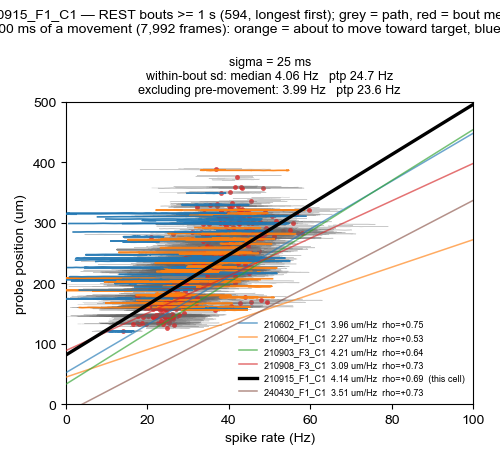

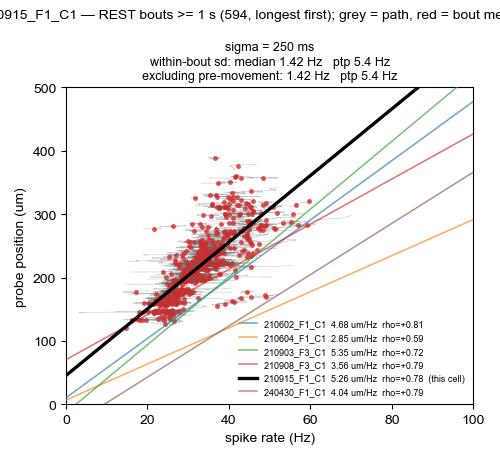

In [27]:
# ============================================================================
# PANEL D / E + the position-vs-rate regression for every cell
# ============================================================================
# Cheap: runs off rest_results, re-smoothing the per-frame counts in memory.
#
# Excluded from every fit: the cue and its off-response, the injected pre-cue
# current step, and the pre-movement run-up. The first two are imposed on the
# cell and the third anticipates a movement that has not happened, so none of
# them report a position/rate relation.
#
# Both slope directions are reported for both kernels because they answer
# different questions and, with a noisy x, are not reciprocals. Regression
# dilution predicts a specific disagreement: slope_pos_on_rate (the line these
# panels draw) is attenuated at 25 ms because its x is noisier, while
# slope_rate_on_pos, where position is the clean variable, should barely move.
# If both shift together, the difference is not measurement noise.

CID_PANEL = '210915_F1_C1'      # the cell whose scatter carries everyone's lines
SIGMAS = (0.025, 0.25)
XLIM, YLIM = (0, 100), (0, 500)
PREMOVE_S = 0.5
CUE_POST_S = 0.2
MIN_BOUT_S = 1.0

_PALETTE = plt.get_cmap('tab10').colors


def prep_records(built, sigmas=SIGMAS):
    """Records carrying one rate column per sigma, plus movement timing."""
    rec = built['records']
    cols = []
    for s in sigmas:
        col = ('rate' if abs(s - ba.SIGMA_S) < 1e-9
               else f'rate_g{int(round(s * 1000))}ms')
        if col not in rec.columns:
            rec = ba.add_smoothed_rate(rec, s, out_col=col)
        cols.append(col)
    if 't_to_move' not in rec.columns:
        rec = ba.add_movement_timing(rec)
    return rec, cols


fits, prepped = [], {}
for cid in cell_list:
    built = rest_results.get(cid)
    if built is None or built.get('records') is None:
        continue
    rec, cols = prep_records(built)
    cue = ba.cue_mask(rec, post_s=CUE_POST_S)
    istep = ba.current_step_mask(rec)
    premove = rec['t_to_move'].to_numpy() <= PREMOVE_S
    keep = ~cue & ~istep & ~premove
    prepped[cid] = {'rec': rec, 'cols': cols, 'keep': keep,
                    'cue': cue, 'istep': istep, 'premove': premove}
    for s, col in zip(SIGMAS, cols):
        f = ba.fit_position_rate(rec, rate_col=col, x_col='x',
                                 state=ba.kin.STATE_REST, mask=keep)
        if f:
            fits.append({'cell': cid, 'sigma_ms': s * 1e3, **f})
fits = pd.DataFrame(fits)

# --- g250 vs g025: the dilution check ---------------------------------------
piv = fits.pivot(index='cell', columns='sigma_ms',
                 values=['slope_pos_on_rate', 'slope_rate_on_pos', 'rho',
                         'rate_sd'])
cmp_fits = pd.DataFrame({
    'pos_on_rate_g025': piv[('slope_pos_on_rate', 25.0)],
    'pos_on_rate_g250': piv[('slope_pos_on_rate', 250.0)],
    'rate_on_pos_g025': piv[('slope_rate_on_pos', 25.0)],
    'rate_on_pos_g250': piv[('slope_rate_on_pos', 250.0)],
    'rho_g025': piv[('rho', 25.0)],
    'rho_g250': piv[('rho', 250.0)],
})
cmp_fits['pos_on_rate_ratio'] = (cmp_fits['pos_on_rate_g250']
                                 / cmp_fits['pos_on_rate_g025'])
cmp_fits['rate_on_pos_ratio'] = (cmp_fits['rate_on_pos_g250']
                                 / cmp_fits['rate_on_pos_g025'])
cmp_fits['var_ratio'] = (piv[('rate_sd', 25.0)] / piv[('rate_sd', 250.0)]) ** 2
print('position vs rate, cue + current step + pre-movement excluded')
display(cmp_fits.round(3))
print('pos_on_rate_ratio should track var_ratio (dilution); '
      'rate_on_pos_ratio should sit at ~1.00')
fits.to_csv('./Figure7/position_rate_fits_A2.csv', index=False)


def fit_lines_for(sigma_ms, highlight=CID_PANEL):
    """One line spec per cell, for whichever kernel a panel is showing.

    The highlighted cell is drawn in black rather than red: red is already the
    bout-mean marker on these panels, and a red line over red markers is not
    readable.
    """
    out = []
    for i, cid in enumerate(c for c in cell_list if c in prepped):
        r = fits[(fits['cell'] == cid) & (fits['sigma_ms'] == sigma_ms)]
        if not len(r):
            continue
        r = r.iloc[0]
        me = cid == highlight
        out.append({'slope': r['slope_pos_on_rate'],
                    'intercept': r['intercept_pos'],
                    'color': 'k' if me else _PALETTE[i % len(_PALETTE)],
                    'lw': 2.4 if me else 1.1,
                    'alpha': 1.0 if me else 0.65,
                    'zorder': 8 if me else 6,
                    'label': (f'{cid}  {r["slope_pos_on_rate"]:.2f} um/Hz'
                              f'  rho={r["rho"]:+.2f}'
                              + ('  (this cell)' if me else ''))})
    return out


def _blank(rec, col, drop):
    """NaN the excluded frames so a bout path breaks instead of jumping a gap."""
    v = rec[col].to_numpy(dtype=float).copy()
    v[drop] = np.nan
    return rec.assign(**{col: v})


p = prepped[CID_PANEL]
col_d, col_e = p['cols'][0], p['cols'][-1]

# Panel D — sigma 25 ms, pre-movement kept and coloured by direction.
rec_d = _blank(p['rec'], col_d, p['cue'] | p['istep'])
figD, spreadD = plot_rate_vs_position_kernels(
    rec_d, CID_PANEL, sigmas_s=(SIGMAS[0],), state=ba.kin.STATE_REST,
    min_duration_s=MIN_BOUT_S, max_bouts=600, xlim=XLIM, ylim=YLIM,
    premove_s=PREMOVE_S, fit_lines=fit_lines_for(SIGMAS[0] * 1e3),
    sinq=sinq, fname_tag='panelD_g025_fits')

# Panel E — sigma 250 ms, pre-movement excluded as well.
rec_e = _blank(p['rec'], col_e, ~p['keep'])
figE, spreadE = plot_rate_vs_position_kernels(
    rec_e, CID_PANEL, sigmas_s=(SIGMAS[1],), state=ba.kin.STATE_REST,
    min_duration_s=MIN_BOUT_S, max_bouts=600, xlim=XLIM, ylim=YLIM,
    premove_s=0, fit_lines=fit_lines_for(SIGMAS[1] * 1e3),
    sinq=sinq, fname_tag='panelE_g250_fits')



# Figure 6 panels

(claude, don't get confused, this used to be figure 7 code, we're reducing the number of cells, I'm keeping track here.)

Cell 1 — conventions + shared axes

In [ ]:
# Shared across every panel, so the figure reads as one thing:
#   orange = about to move TOWARD target      blue = about to move AWAY
#   green  = piezo cue + 200 ms               red  = start-of-trial current step
#   grey   = steady REST / non-highlighted cells
RATE_XLIM = (0, 100)     # Hz, every rate-vs-position panel
POS_YLIM  = (0, 500)     # um
HIGHLIGHT = '210915_F1_C1'
CUE_POST  = 0.2          # the off-response outlasts the 300 ms cue
PREMOVE_S = 0.5

Cell 2 — build records once per cell (the expensive step)

In [ ]:
# a2_cells = [c for c in a2_ids if c != '240430_F1_C1']

# try:
#     rest_results.keys()
# except NameError:
#     rest_results = {}

# for cid in a2_cells:
#     if cid in rest_results and rest_results[cid] is not None:
#         print(f'-- {cid} already built --'); continue
#     print(f'-- {cid} --')
#     rest_results[cid] = build_cell_records(
#         sinq, cid, with_vm=True, pad_spikes=True, trim_edges_s=0.0,
#         keep_table=True, drop_table=False)     # keep_table -> Trial for panel A
#     rec = rest_results[cid]['records']
#     rec = ba.add_smoothed_rate(rec, 0.25, out_col='rate_g250ms')
#     rec = ba.add_smoothed_column(rec, 'vm', 0.25, from_sigma_s=0.025,
#                                  out_col='vm_g250ms')
#     rest_results[cid]['records'] = rec
#     plt.close('all')

In [ ]:
cid, tn = HIGHLIGHT, 222
rec = rest_results[cid]['records']
tr  = T.df.at[tn,'Trial']           #   rest_results[cid]['table'].df.at[tn, 'Trial']

# A: what the analysis sees, with raw voltage and exact-time spikes
plot_trial_records(rec, cid, trial=tn, spike_times=tr, raw_voltage=tr,
                   decimate=5, tag='panelA')
plot_trial_records(rec, cid, trial=tn, t_range=(14, 19), spike_times=tr,
                   raw_voltage=tr, decimate=5, tag='panelA_zoom')

Cell 3 — panels A and B (trial 222)

In [ ]:
figB, statsB = plot_drate_vs_dvm_trial(rec, cid, trial=tn, cue_post_s=CUE_POST,
                                       premove_s=PREMOVE_S, tag='panelB')
display(statsB.round(2))


Cell 4 — panel C: bout coupling across cells (ρ, gain, Vm sd; histograms)

In [ ]:
corr_all = []
for cid, built in rest_results.items():
    if built is None or built['records'] is None:
        continue
    rec = built['records']
    # These are what make the 250 ms comparison possible. Both re-smooth what is
    # already in `rec` (n_sp for rate, the vm column for Vm) — no data pass.
    if 'rate_g250ms' not in rec.columns:
        rec = ba.add_smoothed_rate(rec, 0.25, out_col='rate_g250ms')
    if 'vm_g250ms' not in rec.columns:
        rec = ba.add_smoothed_column(rec, 'vm', 0.25, from_sigma_s=0.025,
                                     out_col='vm_g250ms')
    built['records'] = rec          # keep them, so this is paid once

    c = ba.bout_signal_correlation(rec, [
        ('vm', 'rate', 'sigma 25 ms'),
        ('vm_g250ms', 'rate_g250ms', 'sigma 250 ms')], min_duration_s=1.0)
    c['cell'] = cid
    corr_all.append(c)

corr = pd.concat(corr_all, ignore_index=True)
assert set(corr['label']) == {'sigma 25 ms', 'sigma 250 ms'}, corr['label'].unique()
corr.to_csv('./Figure7/bout_rho_A2.csv', index=False)

figC, tblC = plot_bout_coupling_across_cells(
    corr, highlight=HIGHLIGHT, kind='hist',
    metrics=('rho', 'slope', 'sd_a', 'sd_b'))   # coupling, gain, Vm sd, RATE sd
display(tblC.pivot_table(index=['metric', 'label'], columns='cell',
                         values='median').round(2))

sd_a is the within-bout Vm sd and sd_b the rate sd — add 'sd_b' to metrics for a fourth row. Ranges live in BOUT_METRICS if you want to retune them.

Cell 5 — panels D and E, fixed axes

In [ ]:
for cid, built in rest_results.items():
    if built is None or built['records'] is None:
        continue
    rec = built['records']
    cue_m = ba.cue_mask(rec, post_s=CUE_POST)          # cue + 200 ms
    pm_m  = rec['t_to_move'].to_numpy() <= PREMOVE_S

    # D: 25 ms rate, cue excluded, pre-move coloured by direction
    plot_rate_vs_position_kernels(
        rec[~cue_m], cid, sigmas_s=(0.025,), min_duration_s=1.0, max_bouts=600,
        premove_s=PREMOVE_S, xlim=RATE_XLIM, ylim=POS_YLIM,
        fname_tag='panelD_25ms_noCue', sinq=sinq)

    # D: 25 ms rate, cue and pre-move excluded.
    plot_rate_vs_position_kernels(
        rec[~cue_m], cid, sigmas_s=(0.025,), min_duration_s=1.0, max_bouts=600,
        premove_s=None, xlim=RATE_XLIM, ylim=POS_YLIM,
        fname_tag='panelD_025ms_noCue_noPremove', sinq=sinq)

    # E: 250 ms rate, cue AND pre-move excluded
    plot_rate_vs_position_kernels(
        rec[~cue_m & ~pm_m], cid, rate_cols=['rate_g250ms'], min_duration_s=1.0,
        max_bouts=600, premove_s=None, xlim=RATE_XLIM, ylim=POS_YLIM,
        fname_tag='panelE_250ms_noCue_noPremove', sinq=sinq)
    plt.close('all')

## Single trial stuff

In [ ]:
# cid = '210915_F1_C1'

# example_trial_df = pd.read_csv('Figure7/demo_trials_A2.csv').set_index('cell')
# example_cid_trials = example_trial_df.loc[cid]
# example_cid_trials
# example_trial_df

In [ ]:
# tn = 220

# for idx,row in example_cid_trials.iterrows():
#     tn = row['trial']
#     tr = T.df.at[tn, 'Trial']
#     prev_tr, next_tr = ba.neighbour_trials(T, tn)

#     # long different sigma
#     rec = ba.per_frame_records(tr, sigma_s=0.25, trim_edges_s=0.0, with_vm=True,
#                             vm_kwargs={'blank_pre_s': blank[0], 'blank_post_s': blank[1]},
#                             pad_trials=(prev_tr, next_tr))   # mark_cue=True by default
#     rec['trial'] = tn
#     fig, stats = plot_rate_vs_vm_trial(rec, cid, trial=tn, cue_post_s=0.2)

#     rec = ba.per_frame_records(tr, sigma_s=0.025, trim_edges_s=0.0, with_vm=True,
#                             vm_kwargs={'blank_pre_s': blank[0], 'blank_post_s': blank[1]},
#                             pad_trials=(prev_tr, next_tr))   # mark_cue=True by default
#     rec['trial'] = tn
#     fig, stats = plot_rate_vs_vm_trial(rec, cid, trial=tn, cue_post_s=0.2,save=True)

#     try:
#         plot_trial_vm_overlay(T.df.at[tn, 'Trial'], cid, blank=blank,
#                             sigma_s=0.025, sigma_long_s=0.25, decimate=5,save=True,tag=row['kind'])
#     except KeyError:
#         print(f'no {tn} in df, bad find...')

    # fig, sweep = plot_cue_response(rec, '210915_F1_C1', pre_s=0.19, post_s=0.8, 
    #                                align='onset', baseline_s=0.15)
    # # custom windows:
    # sweep = ba.cue_response_windows(rec, windows={'on': (0, .05), 'late': (.2, .3),
    #                                               'off': (.30, .45)})

# Membrane potential vs. firing rate

`ephys.subthreshold_vm` blanks a window around every detected spike, interpolates across the blanks, smooths with the same σ as the rate (matched bandwidth — otherwise the correlation is limited by whichever kernel is wider) and samples at frame times.

**The blanking window is measured, not assumed.** `spike_triggered_average` averages the voltage aligned to spike peaks and `sta_blank_window` reads the window off it. Each side uses its own reference level: the post-spike extent is measured from the STA's late tail, the pre-spike extent from the pre-spike baseline. They differ because a Vm STA settles onto the slow depolarization that *caused* the spike — measure both sides from the pre-spike baseline and the window runs to the edge of the measured span (blanking a quarter of the recording to remove signal); measure both from the tail and the rising phase passes *through* it, reporting a zero pre-window that leaves the spike's rising edge in "subthreshold" Vm.

**Two artifacts can fabricate a Vm–rate relation, and both are controlled for:**

1. **Blanking bias.** Removing spikes pushes Vm *down* in proportion to rate; leaving them in pushes it *up*. `vm_control=True` computes both, so the pair brackets the truth — a slope keeping its sign and rough size in both is real. `vm_frac_blanked` says how much of the trace is interpolation (high-rate cells here reach 0.4–0.6, so their Vm is largely interpolated even though the relation survives).

2. **Electrode drift.** Vm has no stable zero across an hour of recording. `vm_rate_correlations` splits the correlation into within-trial, between-trial and pooled parts; `plot_vm_drift` shows per-trial Vm and rate against trial number. **Quote the within-trial number.** For a cell whose Vm marches with trial number while its rate falls, the pooled correlation comes out with the *opposite sign* to the relation present inside every trial.


In [ ]:
# Vm-rate correlations for the A2 cells, decomposed.
# Computed here rather than read from the driver, so this works off records built
# by build_cell_records (stage 1) with no window sweep.
vm_rows = []
for cid, res in rest_results.items():
    if res is None or res['records'] is None:
        continue
    rec = res['records']
    row = {'cell': cid,
           'blank_ms': f'-{res["blank"][0]*1e3:.1f}/+{res["blank"][1]*1e3:.1f}',
           'frac_blanked': round(float(rec['vm_frac_blanked'].mean()), 3)}
    row.update({k: (round(v, 3) if isinstance(v, float) else v)
                for k, v in ba.vm_rate_correlations(
                    rec, state=ba.kin.STATE_REST).items()})
    # blanking control: the sign must agree with the blanked version
    if 'vm_noblank' in rec.columns:
        ctl = ba.vm_rate_correlations(rec, state=ba.kin.STATE_REST,
                                      vm_col='vm_noblank')
        row['rho_within_noblank'] = round(ctl.get('rho_within_trial', np.nan), 3)
    vm_rows.append(row)

vm_tbl = pd.DataFrame(vm_rows)
vm_tbl.to_csv('./Figure7/vm_rate_A2.csv', index=False)
display(vm_tbl[['cell', 'blank_ms', 'frac_blanked', 'rate_mean', 'vm_range',
                'rho_within_trial', 'rho_within_noblank', 'rho_between_trial',
                'rho_pooled', 'rho_vm_vs_trial', 'rho_rate_vs_trial',
                'slope_within_trial']])
print('rho_within_trial is the interpretable one; rho_within_noblank is the '
      'blanking control (signs must agree).')
print('|rho_vm_vs_trial| > 0.5 means the pooled/between-trial columns are drift.')


## Directly comparing V_m and spike rate

Overlay the blanked membrane potential over both.


aq  1`# Connecting the dots: trajectories in the rate-vs-position cloud

`plot_rate_vs_position` now overlays the frame-to-frame path through the cloud, so it can be read as trajectories rather than independent points, plus a highlight of the stretches where **position rises while rate falls**. Both are separate legend-toggleable traces in the HTML.

Markers are still subsampled to `max_points_per_state`, but the lines are drawn from the full sequence (longest trajectories first, up to `max_line_points`) — a subsampled path is not a path.

The highlight is deliberately crude: a frame-to-frame sign test plus a minimum length, no smoothing and no threshold. At 25 ms smoothing many of those stretches will be noise. It marks where to look, and is the exploratory first step toward the CCF-style question of whether sustained "movement up / rate down" episodes are real — that needs a proper null (time-reversed or trial-shuffled rate) before any of them can be believed.


In [ ]:
# Re-export the interactive scatter with trajectories, reusing the records the
# driver already built (no second pass over the data).
for cid, res in rest_results.items():
    if res is None:
        continue
    fig = plot_rate_vs_position(res['records'], cid, connect=True,
                                highlight_falling=True)
    fig.write_html(f'./Figure7/rate_vs_position_paths_{cid}{tag_suffix(sinq, cid)}.html')
    print(f'wrote rate_vs_position_paths_{cid}{tag_suffix(sinq, cid)}.html')


In [ ]:
sinq.display_df()

# CCF analyses
Run again now that spikes have been analysed

In [ ]:

# for cid in cell_list:  # in ["210917_F2_C1"]: # 
    # print(f'-- {cid} --')
    # T = sinq.restore_table(dayflycell=cid)
    # T.exclude_trials()
    # T.exclude_ephys_trials()
    # T.extract_trial_properties()

    # rec = collect_cell_records(T)
    # all_records[cid] = rec
    # if len(rec):
    #     fig = plot_rate_vs_position(rec, cid)
    #     fig.write_html(f'./Figure7/rate_vs_position_{cid}{tag_suffix(sinq, cid)}.html')
        
    #     # ccf_results = plot_cell_ccf(rec, cid)
    #     # all records
    #     try:
    #         ccf_results = plot_cell_ccf(rec, cid, fig_dir='./Figure7',
    #               lag_window_s=0.5, n_null=0, save=True,
    #               state=None, sinq=sinq)
    #     except Exception as e:
    #         print(f'   ERROR (plot_cell_ccf): {e}')
        
    #     # just move
    #     # try:
    #     #     ccf_results = plot_cell_ccf(rec, cid, fig_dir='./Figure7',
    #     #           lag_window_s=0.5, n_null=0, save=True, 
    #     #           state=ba.kin.STATE_MOVE, sinq=sinq)
    #     # except Exception as e:
    #     #     print(f'   ERROR (plot_cell_ccf): {e}')

    #     # just stay
    #     # try:
    #     #     ccf_results = plot_cell_ccf(rec, cid, fig_dir='./Figure7',
    #     #           lag_window_s=0.5, n_null=0, save=True, 
    #     #           state=ba.kin.STATE_REST, sinq=sinq)
    #     # except Exception as e:
    #     #     print(f'   ERROR (plot_cell_ccf): {e}')
        
    #     # try:
    #     #     plot_cell_ccf_by_strength(rec, cid, sinq=sinq, n_bins=3)
    #     # except Exception as e:
    #     #     print(f'   ERROR (plot_cell_ccf_by_strength): {e}')

    #     # try:
    #     #     plot_cell_ccf_by_sign(rec, cid, sinq=sinq)
    #     # except Exception as e:
    #     #     print(f'   ERROR (plot_cell_ccf_by_sign): {e}')

    #     # try:
    #     #     plot_velocity_histograms(rec, cid, sinq=sinq)
    #     # except Exception as e:
    #     #     print(f'   ERROR (plot_cell_ccf): {e}')

    #     # try:
    #     #     q_results[cid] = run_cell_quartile_analysis(sinq, cid)
    #     # except Exception as e:
    #     #     print(f'   ERROR (plot_cell_ccf): {e}')
            
    #     # try:
    #     #     stim_results[cid] = run_cell_stim_analysis(sinq, cid)
    #     # except Exception as e:
    #     #     print(f'   ERROR (plot_cell_ccf): {type(e).__name__}: {e}')

    # sinq.drop_tables()

In [ ]:
cid = HIGHLIGHT
rec = rest_results[cid]['records']

masks = ba.condition_masks(rec, cue_post_s=0.2, premove_s=0.5)
print({k: int(v.sum()) for k, v in masks.items()})

# per-condition lag windows: the cue/premove epochs are only ~0.5 s
LW = {'cue': 0.1, 'premove': 0.1, 'rest': 0.5, 'move': 0.4}
ccfs = ba.ccf_by_condition(rec, rate_col='rate', signal_col='x',
                           lag_window_s=LW, min_run_factor=1.0, n_null=100)
figA, tblA = plot_ccf_by_condition(ccfs, cid)
display(tblA)

cue_ev = ba.cue_events(rec)
mv_ev  = ba.movement_onset_events(rec, min_move_ptp=8.0)
lat = {'cue':     ba.event_latency(rec, cue_ev, pre_s=0.15, post_s=0.15),
       'premove': ba.event_latency(rec, mv_ev, pre_s=0.5, post_s=0.5,
                                   min_d_x=4.0)}
figB, tblB = plot_event_latency(lat, cid)
display(tblB)


In [ ]:
figB, tblB = plot_event_latency(lat, cid)


In [ ]:
display(figA)
display(figB)
figA.savefig(f'./Figure7/ccf/{cid}')
figB.savefig(f'./Figure7/ccf/{cid}')


### Batch lead/lag across all A2 cells

The onset latency is the calibrated estimator here; the CCF is descriptive only.
A CCF peak, and a 50%-of-peak crossing, measure how similar two traces are at a
shift, not which one started first -- an adapting rate transient has an earlier
centre of mass than a sustained position step, so both report the rate as
leading even at the cue, where the piezo demonstrably moves first. The table
below shows that disagreement directly: the cue's CCF peaks at a *positive* lag
while its onset latency is negative.


In [26]:
# ============================================================================
# BATCH LEAD/LAG across cells
# ============================================================================
# Calibration conditions, each with a known answer:
#   cue           the piezo moves the probe, so the probe must lead. Timed
#                 against the COMMANDED waveform (ba.add_cue_command), rebuilt
#                 from params -- not against any measured channel. Camera x is
#                 not merely noisy here, it is wrong: it reports the rate as
#                 leading by +15 ms on 70-84% of events, because the probe trace
#                 during the cue mixes the piezo with the fly's own movement.
#                 sgsmonitor tracks the command at r = 0.9995 and gives an
#                 identical answer, so it works as a cross-check, but the command
#                 needs no onset detection at all: its baseline is identically
#                 zero and its onset is an exact instant from params.
#                 sigma <= 50 ms only, because a 250 ms kernel's support reaches
#                 back into the pre-cue current step.
#   current_step  an imposed Vm/rate change with the probe held still -- the
#                 mirror of the cue, and the only control for that direction.
#                 Reported as amplitudes rather than a latency: if the rate drops
#                 by ~15 Hz while the probe moves ~0 um, there is no latency to
#                 measure, which is the point.
#   premove       the rate ramps before a voluntary movement. Its baseline must
#                 sit BEFORE the ramp, or the onset is timed against the very
#                 change being sought.
# Then rest (probe still, so nothing at short lags) and move -- the open
# question, carrying no expectation: A2 is one MN in a population.

LAG_WINDOWS = {'cue': 0.10, 'premove': 0.10, 'rest': 0.50, 'move': 0.40}

LAT_SPECS = (
    # name           events   x_col  pre   post   base_from base_to  dRate  dX
    ('cue',      'cue', 'cue_cmd', 0.10, 0.15,  0.10,     0.0,     2.0,   1.0),
    ('current_step', 'step',  'x',   0.0,  0.085, -0.09,    -0.17,   2.0,   1.5),
    ('premove',      'move',  'x',   0.50, 0.50,  1.00,     0.50,    3.0,   4.0),
)
# NOTE on the two negative values above: event_latency builds its baseline as
# [t0 - base_from_s, t0 - base_to_s), so negative arguments place the window
# AFTER t0. The current step needs that -- there are only ~10 ms of recording
# before it -- and getting the signs wrong yields an empty window, which skips
# every event and looks exactly like a control that passed.


def step_response(rec, window=None, base_s=(-0.90, -0.82)):
    """Signal excursions at the current step, against a post-recovery baseline."""
    lo, hi = ba.CURRENT_STEP_WINDOW if window is None else window
    rows = []
    for tn, g in rec.groupby('trial', sort=True):
        t = g['t'].to_numpy(dtype=float)
        inw = (t >= lo) & (t <= hi)
        inb = (t >= base_s[0]) & (t <= base_s[1])
        if inw.sum() < 5 or inb.sum() < 5:
            continue
        row = {'trial': tn}
        for col in ('rate', 'x', 'vm'):
            if col not in g.columns:
                continue
            y = g[col].to_numpy(dtype=float)
            seg = y[inw] - np.nanmean(y[inb])
            if np.isfinite(seg).any():
                row[f'd_{col}'] = float(seg[int(np.nanargmax(np.abs(seg)))])
        rows.append(row)
    return pd.DataFrame(rows)


def batch_lead_lag(rest_results, cell_list, sinq=None, save=True,
                   n_null=100, verbose=True):
    """Onset latencies + CCFs for every cell."""
    lat_rows, ccf_rows, step_rows, per_cell = [], [], [], {}
    for cid in cell_list:
        built = rest_results.get(cid)
        if built is None or built.get('records') is None:
            continue
        if verbose:
            print(f'-- {cid} --', flush=True)
        rec = built['records']
        if 't_to_move' not in rec.columns:
            rec = ba.add_movement_timing(rec)
        if 'cue_cmd' not in rec.columns:
            rec = ba.add_cue_command(rec)
        events = {'cue': ba.cue_events(rec),
                  'step': ba.current_step_events(rec),
                  'move': ba.movement_onset_events(rec, min_move_ptp=8.0)}

        # Coverage, printed before any latency. A column can exist and still be
        # unfilled -- and "no finite samples in the window" is not the same
        # finding as "no lead", so it has to be visible rather than silently
        # producing an empty condition.
        for c in ('rate', 'x', 'cue_cmd', 'sgs'):
            if c in rec.columns:
                f = float(np.isfinite(rec[c].to_numpy(dtype=float)).mean())
                if f < 0.999:
                    print(f'   coverage {c}: {100 * f:.2f}% finite'
                          f'{"  <-- unusable" if f < 0.5 else ""}')

        lats = {}
        for (name, ekey, x_col, pre, post, bf, bt, dr, dx) in LAT_SPECS:
            ev = events[ekey]
            if not len(ev) or x_col not in rec.columns:
                print(f'   {name}: skipped '
                      f'({"no events" if not len(ev) else x_col + " missing"})')
                continue
            d = ba.event_latency(rec, ev, mode='onset', rate_col='rate',
                                 x_col=x_col, pre_s=pre, post_s=post,
                                 base_from_s=bf, base_to_s=bt, n_sd=3.0,
                                 min_d_rate=dr, min_d_x=dx)
            lats[name] = d
            if not len(d):
                print(f'   {name}: 0 of {len(ev)} events timed '
                      f'(check the {x_col} coverage above and the '
                      f'baseline window signs)')
            v = (d['latency_ms'].replace([np.inf, -np.inf], np.nan).dropna()
                 if len(d) else pd.Series(dtype=float))
            lat_rows.append({
                'cell': cid, 'condition': name, 'x_col': x_col,
                'n_events': len(ev), 'n_timed': len(v),
                'median_ms': float(np.median(v)) if len(v) else np.nan,
                'iqr_ms': (float(np.subtract(*np.percentile(v, [75, 25])))
                           if len(v) else np.nan),
                'frac_rate_first': float((v > 0).mean()) if len(v) else np.nan})

        # CCF, descriptive. current_step is left out: its epochs are ~75 ms,
        # far too short to support any lag window.
        conds = ba.condition_masks(rec, cue_post_s=0.2, premove_s=0.5)
        conds.pop('current_step', None)
        ccfs = ba.ccf_by_condition(rec, conditions=conds, rate_col='rate',
                                   signal_col='x', lag_window_s=LAG_WINDOWS,
                                   min_run_factor=1.0, n_null=n_null)
        for name, d in ccfs.items():
            if d.get('ccf') is None:
                continue
            ccf_rows.append({'cell': cid, 'condition': name,
                             'lag_peak_ms': d.get('lag_peak', np.nan) * 1e3,
                             'r_peak': d.get('r_peak', np.nan),
                             'lag_cv_ms': d.get('lag_cv', np.nan) * 1e3,
                             'r_cv': d.get('r_cv', np.nan),
                             'n_runs': d['n_runs'],
                             'n_too_short': d['n_too_short']})

        sr = step_response(rec)
        if len(sr):
            row = {'cell': cid, 'n_trials': len(sr)}
            for c in ('d_rate', 'd_x', 'd_vm'):
                if c in sr.columns:
                    row[f'median_{c}'] = float(sr[c].median())
            step_rows.append(row)

        per_cell[cid] = {'lats': lats, 'ccfs': ccfs, 'step': sr}
        if save:
            o = plot_ccf_by_condition(ccfs, cid, sinq=sinq, fname_tag='ccf_batch')
            if o:
                plt.close(o[0])
            o = plot_event_latency(lats, cid, sinq=sinq,
                                   fname_tag='latency_batch')
            if o:
                plt.close(o[0])
    return (pd.DataFrame(lat_rows), pd.DataFrame(ccf_rows),
            pd.DataFrame(step_rows), per_cell)


lat_tbl, ccf_tbl, step_tbl, leadlag = batch_lead_lag(
    rest_results, cell_list, sinq=sinq, save=True)

print('\n=== ONSET LATENCY (+ve = rate first) ===')
display(lat_tbl.round(1))
print('=== CURRENT-STEP CONTROL: rate and Vm move, probe should not ===')
display(step_tbl.round(2))
print('=== CCF (descriptive only -- peaks measure shape, not onset) ===')
display(ccf_tbl.round(1))
for nm, t in (('latency', lat_tbl), ('ccf', ccf_tbl), ('step', step_tbl)):
    t.to_csv(f'./Figure7/leadlag_{nm}_A2.csv', index=False)


-- 210602_F1_C1 --
-- 210604_F1_C1 --
-- 210903_F3_C1 --
-- 210908_F3_C1 --
-- 210915_F1_C1 --
-- 240430_F1_C1 --

=== ONSET LATENCY (+ve = rate first) ===


,cell,condition,x_col,n_events,n_timed,median_ms,iqr_ms,frac_rate_first
0,210602_F1_C1,cue,cue_cmd,650,524,-5.2,17.8,0.0
1,210602_F1_C1,current_step,x,644,49,0.0,0.0,0.0
2,210602_F1_C1,premove,x,416,192,0.0,98.6,0.5
3,210604_F1_C1,cue,cue_cmd,329,261,-10.2,25.5,0.0
4,210604_F1_C1,current_step,x,327,10,0.0,0.0,0.2
5,210604_F1_C1,premove,x,96,23,10.2,137.7,0.6
6,210903_F3_C1,cue,cue_cmd,600,482,-15.0,25.1,0.0
7,210903_F3_C1,current_step,x,598,13,0.0,0.0,0.2
8,210903_F3_C1,premove,x,241,82,-40.0,204.3,0.4
9,210908_F3_C1,cue,cue_cmd,200,162,-10.0,23.8,0.0


=== CURRENT-STEP CONTROL: rate and Vm move, probe should not ===


,cell,n_trials,median_d_rate,median_d_x,median_d_vm
0,210602_F1_C1,649,-21.85,0.00,-2.51
1,210604_F1_C1,329,-23.39,0.21,-2.70
2,210903_F3_C1,598,-15.24,0.04,-1.42
3,210908_F3_C1,199,-15.01,0.06,-3.23
4,210915_F1_C1,347,-15.25,0.16,-3.17
5,240430_F1_C1,285,-17.03,0.00,-1.16


=== CCF (descriptive only -- peaks measure shape, not onset) ===


,cell,condition,lag_peak_ms,r_peak,lag_cv_ms,r_cv,n_runs,n_too_short
0,210602_F1_C1,cue,60.7,-0.6,60.7,-0.6,636,0
1,210602_F1_C1,premove,75.9,0.1,75.9,0.1,268,136
2,210602_F1_C1,rest,126.5,0.1,126.5,0.0,831,1521
3,210602_F1_C1,move,91.1,0.6,86.0,0.6,195,227
4,210604_F1_C1,cue,56.1,-0.7,56.1,-0.7,329,0
5,210604_F1_C1,premove,76.5,0.1,76.5,0.1,45,30
6,210604_F1_C1,rest,-198.9,-0.1,-193.8,-0.1,401,3092
7,210604_F1_C1,move,81.6,0.2,76.5,0.2,68,25
8,210903_F3_C1,cue,65.0,-0.7,65.0,-0.7,593,0
9,210903_F3_C1,premove,70.0,0.1,80.0,0.1,170,77


## Membrane fluctuation during REST, for the A4 comparison

`[A2-VM-1]` — writes `./Figure7/bout_vm_spread_A2.csv`, which the A4
notebook's `A4-VM-1` reads. Same function, same exclusions, both sets.


In [ ]:
# [A2-VM-1]
# ============================================================================
# Per-REST-bout membrane fluctuation, written for the A4 comparison
# ============================================================================
# The A4 notebook's A4-VM-1 asks how much the membrane moves during rest, and
# needs the A2 numbers to compare against. bout_vm_spread lives in
# figure7_analysis so both notebooks run the SAME code -- same bout definition,
# same exclusions (cue + off-response + injected current step), same columns --
# rather than two implementations that drift apart.
#
# Both `vm` and `vm_noblank` are returned, and the comparison needs both. `vm`
# is spike-blanked: every spike is cut out and interpolated across, which on
# this set is not a detail -- frac_blanked is ~0.40 on 210915_F1_C1. Blanking
# removes the fastest excursions, so it biases the A2 sd DOWNWARD relative to
# A4, which barely fires and is therefore barely blanked. `vm_noblank` carries
# the opposite bias. A difference that survives in both is not an artifact of
# either.
#
# Writes the CSV A4-VM-1 looks for. Cheap: it runs off records already in
# memory and rebuilds nothing.

from figure7_analysis import bout_vm_spread

vm_a2 = bout_vm_spread(rest_results, cell_list, group='A2')
if not len(vm_a2):
    raise RuntimeError('no Vm bouts -- were these records built with '
                       'with_vm=True (and vm_control=True for vm_noblank)?')
vm_a2.to_csv('./Figure7/bout_vm_spread_A2.csv', index=False)

summary_vm_a2 = (vm_a2.groupby(['cell', 'vm_col'])
                 .agg(bouts=('vm_sd', 'size'),
                      median_sd=('vm_sd', 'median'),
                      median_ptp=('vm_ptp', 'median'),
                      median_iqr=('vm_iqr', 'median'),
                      median_bout_s=('duration', 'median'),
                      frac_blanked=('frac_blanked', 'first'))
                 .round(3))
print(f'{len(vm_a2)} bout x column rows -> ./Figure7/bout_vm_spread_A2.csv')
print('frac_blanked is the size of the blanking bias for each cell; compare A2')
print('and A4 within the same vm_col, and require vm and vm_noblank to agree.')
display(summary_vm_a2)

# Start working on A4 neurons

In [ ]:
sinq.display_df()
cell_list = [
    # '210302_F1_C2',
    # '210319_F2_C1',
    # '210331_F2_C1',
    # '210405_F1_C1',
    # '210602_F1_C1',   # a2
    # '210604_F1_C1',   # a2
    # '210903_F3_C1',   # a2
    # '210908_F3_C1',   # A2
    # '210915_F1_C1',     # 78E05
    '210917_F2_C1', # A4
    # '240430_F1_C1',
    '241115_F1_C1', # A4
    '241203_F2_C1' # A4
    ]
